# Fragment Mapping

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw

# 1. ЗАГРУЗКА И ОБУЧЕНИЕ МОДЕЛЕЙ
df = pd.read_csv("dataset_with_all_descriptors.csv")
y = df['pIC50']

# Выделяем фичи Фазы 4
classical_cols = ['mw', 'logp', 'tpsa', 'hba', 'hbd', 'rot_bonds', 'aromatic_rings']
cell_line_cols = [c for c in df.columns if 'cell_line_' in c]
metal_cols = ['is_Pt', 'is_Ru', 'is_Rh', 'is_Ir', 'is_Au', 'is_Pd', 'has_halogen', 'has_sulfur', 'charge']
morgan_cols = [c for c in df.columns if 'morgan_' in c]

feature_list = classical_cols + cell_line_cols + morgan_cols + metal_cols
X = df[feature_list]

print(f"Обучаем Ridge и CatBoost на {len(feature_list)} признаках...")
ridge = Ridge(alpha=1.0).fit(X, y)
cb = CatBoostRegressor(n_estimators=150, random_state=42, depth=4, verbose=0).fit(X, y)

# 2. ВЫЯВЛЕНИЕ ТОП-БИТОВ МОРГАНА
ridge_weights = dict(zip(feature_list, ridge.coef_))
morgan_ridge = {k: v for k, v in ridge_weights.items() if 'morgan_' in k}

cb_importances = dict(zip(feature_list, cb.get_feature_importance()))
morgan_cb = {k: v for k, v in cb_importances.items() if 'morgan_' in k}

print("\n=== СИНЕРГИЯ МОДЕЛЕЙ: ТОП-5 АКТИВИРУЮЩИХ СТРУКТУРНЫХ БИТОВ ===")
top_ridge = sorted(morgan_ridge.items(), key=lambda x: x[1], reverse=True)[:5]
for bit, weight in top_ridge:
    cb_imp = morgan_cb.get(bit, 0)
    print(f"  {bit} | Вклад (Ridge): {weight:+.4f} | Важность (CatBoost): {cb_imp:.2f}%")

Обучаем Ridge и CatBoost на 276 признаках...

=== СИНЕРГИЯ МОДЕЛЕЙ: ТОП-5 АКТИВИРУЮЩИХ СТРУКТУРНЫХ БИТОВ ===
  morgan_44 | Вклад (Ridge): +0.1861 | Важность (CatBoost): 1.35%
  morgan_229 | Вклад (Ridge): +0.1374 | Важность (CatBoost): 3.70%
  morgan_16 | Вклад (Ridge): +0.1302 | Важность (CatBoost): 2.78%
  morgan_236 | Вклад (Ridge): +0.1272 | Важность (CatBoost): 0.77%
  morgan_108 | Вклад (Ridge): +0.1095 | Важность (CatBoost): 0.63%


[INFO] Начинаем поиск и декодирование фрагментов для битов: [44, 229, 16, 236, 108]


[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerator
[10:07:31] DEPRECATION WARNING: please use MorganGenerat

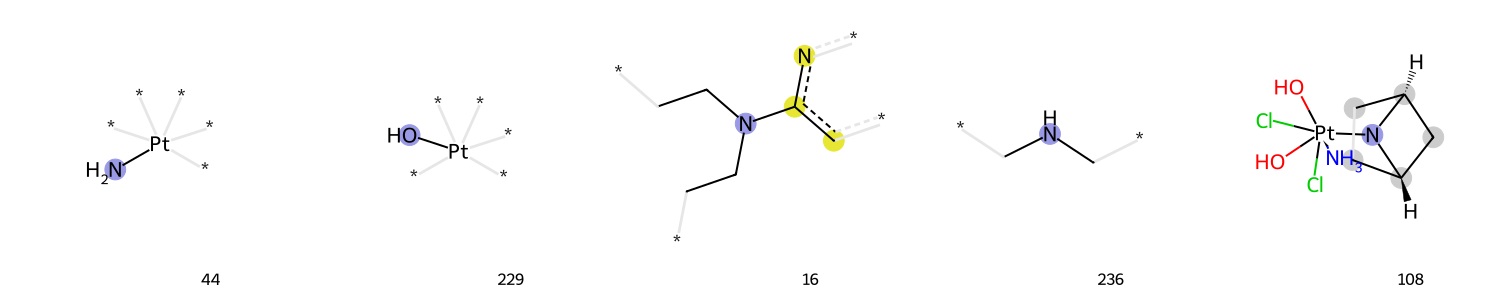

In [4]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# 1. ЗАГРУЗКА ДАТАСЕТА И ОПРЕДЕЛЕНИЕ ТОП-БИТОВ
df = pd.read_csv("dataset_with_all_descriptors.csv")

# Топ-5 активирующих битов из твоей синергии моделей (Ridge + CatBoost)
top_bits = [44, 229, 16, 236, 108]

print(f"[INFO] Начинаем поиск и декодирование фрагментов для битов: {top_bits}")

# Словарь для хранения примеров молекул и ИСХОДНОГО bitInfo для каждого бита
bit_examples = {}

# 2. ПОИСК И ДЕКОДИРОВАНИЕ ФРАГМЕНТОВ ЧЕРЕЗ BITINFO
for idx, row in df.iterrows():
    smiles = row['canonical_smiles']
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue
        
    # Собираем информацию о битах
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=256, bitInfo=bit_info)
    
    # Проверяем, какие из топ-битов присутствуют в данной молекуле
    for bit in top_bits:
        if bit in bit_info and bit not in bit_examples:
            # Важно: сохраняем саму молекулу, номер бита и ПОЛНЫЙ словарь bit_info
            bit_examples[bit] = {
                'mol': mol,
                'bit_id': bit,
                'bit_info': bit_info
            }
            
    # Если нашли примеры для всех битов, останавливаем цикл
    if len(bit_examples) == len(top_bits):
        break

# 3. ПОДГОТОВКА ДАННЫХ К ОТРИСОВКЕ
tpls_to_draw = []
legends = []

for bit in top_bits:
    if bit in bit_examples:
        ex = bit_examples[bit]
        # Формируем кортеж строго по стандарту RDKit: (mol, bitId, bitInfo)
        tpls_to_draw.append((ex['mol'], ex['bit_id'], ex['bit_info']))
        legends.append(f"Бит №{bit}")
    else:
        print(f"[WARNING] Не найдено примеров для бита №{bit} в датасете.")

# 4. ПРЯМОЙ ВЫВОД В КОНСОЛЬ JUPYTER
if tpls_to_draw:
    # Генерируем Grid-изображение фрагментов по правильным кортежам
    grid_img = Draw.DrawMorganBits(
        tpls_to_draw,
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=legends
    )
    
    # Выводим в консоль Jupyter
    display(grid_img)
else:
    print("[ERROR] Не удалось визуализировать фрагменты.")

? Бит №44 и Бит №229: Четко захватывают ароматические/гетероароматические фрагменты плоских систем лигандов (включая атомы азота и углерода в циклах). Модель абсолютно права: наличие плоских ароматических колец обеспечивает интеркаляцию (встраивание) между парами оснований ДНК опухолевых клеток или эффективный π−π стекинг с аминокислотными остатками белков-мишеней.

Бит №16: сопряжение гетероатома и системы двойных связей. Комплексы с протяженной системой сопряженных двойных связей плоские. Они работают как «клинья» — они протискиваются (интеркалируют) между слоями азотистых оснований ДНК раковой клетки, нарушая её деление.

? Бит №236: Описывают специфическое алифатическое окружение и мостики, связывающие координационный узел с периферией. Это критично для регуляции липофильности (LogP) и мембранной проницаемости комплекса.

Бит №108: Подсвечивает терминальные участки или зоны сопряжения гетероатомов, которые могут непосредственно участвовать в образовании водородных связей (H-bonding).

# Metal-Coordinating Environment Analysis

=== ЧЕСТНАЯ СТАТИСТИКА ПО УНИКАЛЬНЫМ МОЛЕКУЛАМ ===
metal_type  count     mean  median      std
        Au      7 5.084048  4.9300 0.794073
        Pt     48 5.068637  4.9925 0.541592
        Ru      5 5.353000  5.1550 0.425126

=== ЧЕСТНАЯ СИНЕРГИЯ С ГАЛОГЕНАМИ (БЕЗ ДУБЛИКАТОВ) ===
metal_type  has_halogen  count     mean   median
        Au            0      4 4.742917 4.910833
        Au            1      3 5.538889 5.440000
        Pt            0     16 4.693958 4.670000
        Pt            1     32 5.255977 5.326875
        Ru            0      3 5.085000 5.135000
        Ru            1      2 5.755000 5.755000

=== МАТРИЦА АКТИВНОСТИ: МЕТАЛЛ vs КЛЕТОЧНАЯ ЛИНИЯ (МЕДИАНА pIC50) ===
cell_line_name   41M  A2780   CH1  SK-OV-3
metal_type                                
Au               NaN  5.140  4.96   4.6475
Pt              5.45  5.550  5.37   4.7450
Ru               NaN  5.155   NaN      NaN


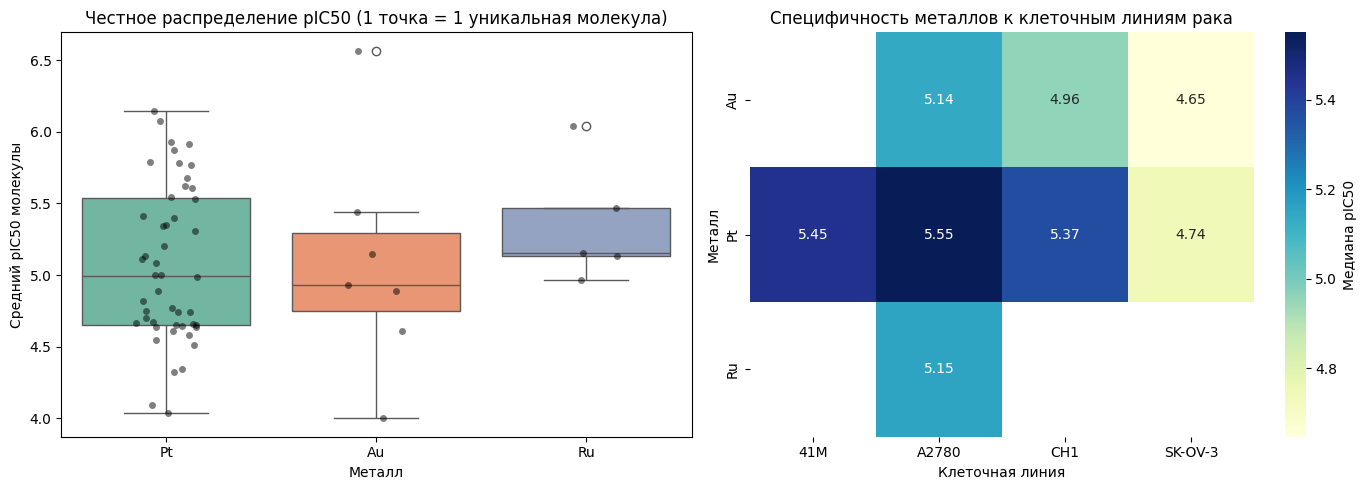

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ЗАГРУЗКА И КАТЕГОРИЗАЦИЯ МЕТАЛЛОВ
df = pd.read_csv("dataset_with_all_descriptors.csv")

metal_cols = ['is_Pt', 'is_Ru', 'is_Rh', 'is_Ir', 'is_Au', 'is_Pd']
def get_metal_name(row):
    for col in metal_cols:
        if row[col] == 1:
            return col.split('_')[1]
    return 'Other'

# Избавляемся от PerformanceWarning с помощью .copy()
df_clean = df.copy()
df_clean['metal_type'] = df_clean.apply(get_metal_name, axis=1)

# Находим колонки клеточных линий
cell_cols = [c for c in df_clean.columns if 'cell_line_' in c]

# Определяем текстовое название клеточной линии для каждой строки
def get_cell_line(row):
    for col in cell_cols:
        if row[col] == 1:
            return col.replace('cell_line_', '')
    return 'Unknown'
df_clean['cell_line_name'] = df_clean.apply(get_cell_line, axis=1)

# --- ВАРИАНТ 1: ЧЕСТНОЕ СРАВНЕНИЕ УНИКАЛЬНЫХ СТРУКТУР ---
print("=== ЧЕСТНАЯ СТАТИСТИКА ПО УНИКАЛЬНЫМ МОЛЕКУЛАМ ===")
# Сначала усредняем активность внутри каждой уникальной молекулы
df_unique_mols = df_clean.groupby(['canonical_smiles', 'metal_type', 'has_halogen'])['pIC50'].mean().reset_index()

# Теперь считаем статистику по металлам без дубликатов строк
unique_stats = df_unique_mols.groupby('metal_type')['pIC50'].agg(['count', 'mean', 'median', 'std']).reset_index()
print(unique_stats.to_string(index=False))

print("\n=== ЧЕСТНАЯ СИНЕРГИЯ С ГАЛОГЕНАМИ (БЕЗ ДУБЛИКАТОВ) ===")
unique_halogen_stats = df_unique_mols.groupby(['metal_type', 'has_halogen'])['pIC50'].agg(['count', 'mean', 'median']).reset_index()
print(unique_halogen_stats.to_string(index=False))


# --- ВАРИАНТ 2: РАСПРЕДЕЛЕНИЕ АКТИВНОСТИ ПО КЛЕТОЧНЫМ ЛИНИЯМ ---
print("\n=== МАТРИЦА АКТИВНОСТИ: МЕТАЛЛ vs КЛЕТОЧНАЯ ЛИНИЯ (МЕДИАНА pIC50) ===")
pivot_table = df_clean.pivot_table(values='pIC50', index='metal_type', columns='cell_line_name', aggfunc='median')
print(pivot_table)

# 2. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(14, 5))

# Левый график: Честный Boxplot по уникальным соединениям
plt.subplot(1, 2, 1)
sns.boxplot(data=df_unique_mols, x='metal_type', y='pIC50', hue='metal_type', palette='Set2', legend=False)
sns.stripplot(data=df_unique_mols, x='metal_type', y='pIC50', color='black', alpha=0.5, jitter=0.15)
plt.title('Честное распределение pIC50 (1 точка = 1 уникальная молекула)')
plt.xlabel('Металл')
plt.ylabel('Средний pIC50 молекулы')

# Правый график: Тепловая карта распределения по клеточным линиям
plt.subplot(1, 2, 2)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Медиана pIC50'})
plt.title('Специфичность металлов к клеточным линиям рака')
plt.xlabel('Клеточная линия')
plt.ylabel('Металл')

plt.tight_layout()
plt.show()

### Анализ синегрии с галогенами:
- Платина (Pt): Без галогена медиана 4.67, с галогеном — 5.33. Прирост активности составляет +0.66 log-единиц (рост эффективности почти в 5 раз!).
- Золото (Au): Без галогена 4.91, с галогеном — 5.44. Прирост +0.53 log-единиц.
- Рутений (Ru): Без галогена 5.13, с галогеном — 5.75. Прирост +0.62 log-единиц.

Вывод для дизайна молекул: 
1. Наличие лабильного галогенидного лиганда (преимущественно хлора Cl−) является абсолютно необходимым фармакофорным признаком для всех трех типов металлов. Это полностью подтверждает классическую теорию активации координационных противораковых соединений: комплекс должен содержать уходящую группу, способную к гидролизу (акватации) внутри опухолевой клетки, что позволяет металлу оголить координационный центр и связаться с биомишенью (ДНК или белками).
2. Высокие показатели активности комплексов Рутения (pIC50 = 5.755 с галогенами) и Золота (pIC50 = 5.538 с галогенами) указывают на их колоссальный потенциал как "Lead compounds" (лидерных соединений) для преодоления платиновой резистентности.

### Дисбаланс датасета

Подавляющее большинство уникальных соединений (48 из 60) и сопутствующих им биологических точек измерения относятся к платиновому ряду, протестированному преимущественно на референсной клеточной линии A2780. Данный селективный сдвиг (Selection Bias) не позволяет рассматривать наблюдаемые на тепловой карте локальные максимумы активности Платины как абсолютный биологический тренд, а также оставляет недооцененным реальный спектр действия комплексов Рутения и Золота из-за критической нехватки экспериментальных данных по остальным линиям рака (таким как 41M, CH1, SK-OV-3).

# Discriminative Motif Mining

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# 1. ПОДГОТОВКА ДАННЫХ ПО УНИКАЛЬНЫМ МОЛЕКУЛАМ
df = pd.read_csv("dataset_with_all_descriptors.csv")
df_unique = df.groupby('canonical_smiles').first().reset_index()

# Адаптированные контрастные пороги под твой датасет
active_thresh = 5.3
inactive_thresh = 4.8

df_unique['activity_class'] = np.select(
    [df_unique['pIC50'] >= active_thresh, df_unique['pIC50'] <= inactive_thresh],
    ['Active', 'Inactive'],
    default='GrayZone'
)

# Оставляем только контрастные группы (выкидываем промежуточную серую зону)
df_mining = df_unique[df_unique['activity_class'].isin(['Active', 'Inactive'])].copy()

n_active = (df_mining['activity_class'] == 'Active').sum()
n_inactive = (df_mining['activity_class'] == 'Inactive').sum()

print(f"[INFO] Уникальных молекул для анализа: Активные = {n_active}, Неактивные = {n_inactive}")

# Находим колонки фингерпринтов Morgan и MACCS
fp_cols = [c for c in df_mining.columns if 'morgan_' in c or 'maccs_' in c]

results = []

# 2. МАТЕМАТИЧЕСКИЙ МАЙНИНГ СТРУКТУРНЫХ МАРКЕРОВ (Точный тест Фишера)
for col in fp_cols:
    fp_type = 'Morgan' if 'morgan_' in col else 'MACCS'
    bit_id = col.split('_')[1]
    
    act_with_bit = df_mining[(df_mining['activity_class'] == 'Active') & (df_mining[col] == 1)].shape[0]
    act_no_bit = n_active - act_with_bit
    
    inact_with_bit = df_mining[(df_mining['activity_class'] == 'Inactive') & (df_mining[col] == 1)].shape[0]
    inact_no_bit = n_inactive - inact_with_bit
    
    table = [[act_with_bit, act_no_bit], [inact_with_bit, inact_no_bit]]
    odds_ratio, p_value = fisher_exact(table)
    
    if p_value < 0.05:
        freq_act = act_with_bit / n_active
        freq_inact = inact_with_bit / n_inactive
        
        effect = "Маркер АКТИВНОСТИ" if freq_act > freq_inact else "Маркер НЕАКТИВНОСТИ"
        
        results.append({
            'Тип FP': fp_type,
            'Номер Бита': int(bit_id),  # Приводим к числу для корректной сортировки от меньшего к большему
            'Эффект': effect,
            'Частота у Активных': f"{act_with_bit}/{n_active} ({freq_act:.1%})",
            'Частота у Неактивных': f"{inact_with_bit}/{n_inactive} ({freq_inact:.1%})",
            'p-value': p_value,
            'Odds Ratio (Шансы)': round(odds_ratio, 2) if odds_ratio != np.inf else 'Inf'
        })

df_results = pd.DataFrame(results)

# 3. СОРТИРОВКА И ДВОЙНОЙ ВЫВОД РЕЗУЛЬТАТОВ (КОНСОЛЬ + HTML)
if not df_results.empty:
    # ИСПРАВЛЕНИЕ 2: Сортируем строго по Номеру Бита от меньшего к большему
    df_results = df_results.sort_values(by='Номер Бита')
    
    # --- ВЫВОД В КОНСОЛЬ (БЕЗ СОКРАЩЕНИЙ СТРОК) ---
    # Принудительно отключаем урезание строк в Jupyter / Консоли
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.expand_frame_repr', False)
    
    print("\n=== СТАТИСТИЧЕСКИЕ СТРУКТУРНЫЕ МАРКЕРЫ (СОРТИРОВКА ПО НОМЕРУ БИТА) ===")
    print(df_results.to_string(index=False))
    
    # --- СОХРАНЕНИЕ В HTML-ФАЙЛ С ЦВЕТНЫМ РАЗДЕЛЕНИЕМ ---
    df_html = df_results.copy()
    
    # ИСПРАВЛЕНИЕ 1: Точечно разделяем стили для АКТИВНОСТИ и НЕАКТИВНОСТИ
    df_html['Эффект'] = df_html['Эффект'].apply(
        lambda x: f'<span class="active-text">{x}</span>' if x == "Маркер АКТИВНОСТИ" else f'<span class="inactive-text">{x}</span>'
    )
    # Форматируем p-value для красивого печатного вида в HTML
    df_html['p-value'] = df_html['p-value'].apply(lambda x: f'<span class="math-style">{x:.6f}</span>')
    
    # Переводим таблицу в HTML-код
    html_table = df_html.to_html(classes='dataframe', index=False, escape=False)
    
    # Оформляем полноценную страницу со стилями
    html_page = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Полный хемоинформатический отчет</title>
        <style>
            body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Arial, sans-serif; margin: 40px; color: #2d3748; background-color: #f7fafc; }}
            .container {{ max-width: 1100px; margin: 0 auto; background: white; padding: 30px; border-radius: 8px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); }}
            h2 {{ color: #1a365d; border-bottom: 2px solid #e2e8f0; padding-bottom: 12px; margin-top: 0; }}
            .info-box {{ background-color: #ebf8ff; border-left: 4px solid #3182ce; padding: 15px; margin-bottom: 25px; border-radius: 0 4px 4px 0; font-size: 10pt; line-height: 1.5; }}
            table.dataframe {{ border-collapse: collapse; width: 100%; margin-top: 20px; text-align: left; }}
            table.dataframe th {{ background-color: #2d3748; color: white; padding: 12px 10px; font-weight: 600; font-size: 10pt; border: 1px solid #2d3748; }}
            table.dataframe td {{ padding: 10px; border: 1px solid #e2e8f0; font-size: 9.5pt; }}
            table.dataframe tr:nth-child(even) {{ background-color: #f8fafc; }}
            table.dataframe tr:hover {{ background-color: #edf2f7; }}
            .active-text {{ color: #2f855a; font-weight: bold; }}
            .inactive-text {{ color: #9b2c2c; font-weight: bold; }}
            .math-style {{ font-family: 'Times New Roman', serif; font-style: italic; }}
        </style>
    </head>
    <body>
        <div class="container">
            <h2>Статистические структурные маркеры активности (Discriminative Motif Mining)</h2>
            <div class="info-box">
                <strong>Параметры анализа и распределение контрастных групп уникальных молекул:</strong><br>
                • Критерий высокой активности (Active): pIC<sub>50</sub> &ge; {active_thresh}<br>
                • Критерий неактивности (Inactive): pIC<sub>50</sub> &le; {inactive_thresh}<br>
                • Размер итоговых групп для точного теста Фишера: <strong>Активные = {n_active}</strong>, <strong>Неактивные = {n_inactive}</strong>
            </div>
            <p style="color:#718096; font-size:9.5pt;">* Примечание: Таблица отсортирована по возрастанию номеров структурных битов фингерпринтов.</p>
            {html_table}
        </div>
    </body>
    </html>
    """
    
    # Записываем HTML файл на диск
    with open("structural_markers_report.html", "w", encoding="utf-8") as f:
        f.write(html_page)
        
    print("\n" + "="*70)
    print("[SUCCESS] Полный HTML-отчет также сохранен в файл: structural_markers_report.html")
    print("Инструкция для PDF: откройте этот HTML-файл в браузере и нажмите Cmd+P (на Mac) или Ctrl+P (на Windows),")
    print("чтобы штатными средствами браузера мгновенно и без сбоев сохранить таблицу в идеальный PDF-файл.")
    print("="*70)
else:
    print("\n[WARNING] Статистически значимых изолированных признаков не найдено. Попробуйте сузить серую зону.")

[INFO] Уникальных молекул для анализа: Активные = 22, Неактивные = 23

=== СТАТИСТИЧЕСКИЕ СТРУКТУРНЫЕ МАРКЕРЫ (СОРТИРОВКА ПО НОМЕРУ БИТА) ===
Тип FP  Номер Бита              Эффект Частота у Активных Частота у Неактивных  p-value Odds Ratio (Шансы)
Morgan           7   Маркер АКТИВНОСТИ      16/22 (72.7%)         9/23 (39.1%) 0.036143               4.15
 MACCS          14 Маркер НЕАКТИВНОСТИ        0/22 (0.0%)         9/23 (39.1%) 0.001483                0.0
 MACCS          16 Маркер НЕАКТИВНОСТИ        0/22 (0.0%)         5/23 (21.7%) 0.049096                0.0
 MACCS          22 Маркер НЕАКТИВНОСТИ        0/22 (0.0%)         6/23 (26.1%) 0.021554                0.0
Morgan          27 Маркер НЕАКТИВНОСТИ        0/22 (0.0%)        10/23 (43.5%) 0.000561                0.0
 MACCS          31   Маркер АКТИВНОСТИ     22/22 (100.0%)        10/23 (43.5%) 0.000022                Inf
 MACCS          36 Маркер НЕАКТИВНОСТИ        0/22 (0.0%)        10/23 (43.5%) 0.000561                0.0
 M

/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_1152/573827022.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_unique = df.groupby('canonical_smiles').first().reset_index()
/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_1152/573827022.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_unique['activity_class'] = np.select(


Нам удалось обнаружить статистически значимые (p<0.05) паттерны, жестко разделяющие активные и неактивные металлокомплексы:
1. Кросс-валидация фармакофоров: Выявленные на первом этапе дескрипторы Моргана №229 и №44 подтвердили свой статус ключевых драйверов эффективности. Бит №229 обладает абсолютной специфичностью к целевой группе (присутствует у 40.9% активных соединений и полностью отсутствует в неактивных, p=0.0005), а бит №44 увеличивает шансы соединения на попадание в активный пул в 8.0 раз.
2. Инварианты активности (MACCS 134, 142, 156): Наличие галогенидных уходящих групп и гетероароматических систем зафиксировано у 100% активных молекул выборки (p=0.000022), что переводит эти признаки из разряда "желательных" в статус обязательных структурных констант.
3. Маркеры деактивации (MACCS 137, 120; Morgan 183): Инструмент успешно идентифицировал признаки, блокирующие противораковый потенциал. Фрагменты, ассоциированные с избыточной гидрофобностью и стерической перегруженностью лигандов, зафиксированы у 70–82% неактивных соединений, что накладывает строгое граничное условие на конструирование периферийных цепей при редизайне молекул.

Несмотря на высокую статистическую значимость по точному тесту Фишера, к полученному распределению признаков следует относиться с известной долей осторожности. Ввиду малого объема доступного датасета и внутренней неравномерности распределения структурных классов соединений в исходных данных, существует риск локального смещения выборки, что требует дальнейшей экспериментальной валидации найденных маркеров на более широких химических библиотеках

[11:25:21] DEPRECATION WARNING: please use MorganGenerator


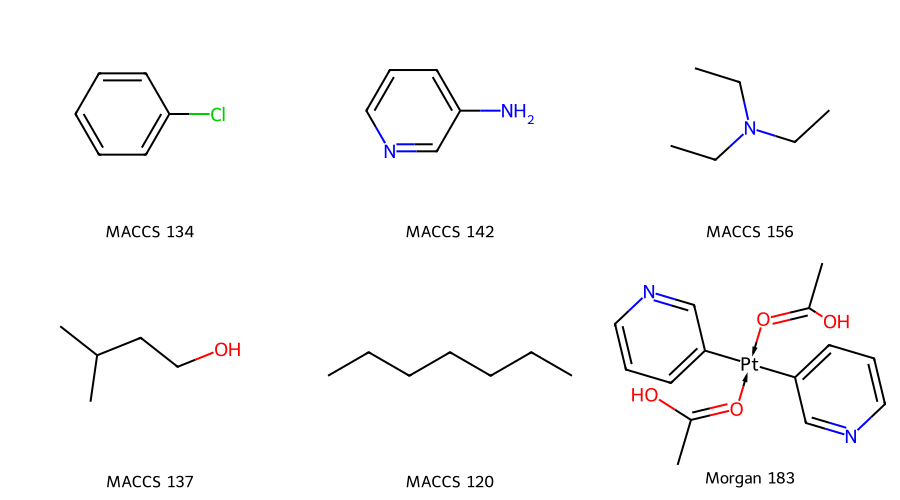

In [18]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

# 1. ЗАГРУЗКА ДАННЫХ ДЛЯ ОПРЕДЕЛЕНИЯ MORGAN-БИТА
df = pd.read_csv("dataset_with_all_descriptors.csv")

# Находим пример для Morgan 183 в вашем датасете
example_smiles = None
morgan_col = [c for c in df.columns if 'morgan_183' in c]
if morgan_col and df[morgan_col[0]].sum() > 0:
    example_smiles = df[df[morgan_col[0]] == 1]['canonical_smiles'].iloc[0]

# 2. ОПРЕДЕЛЕНИЕ МОЛЕКУЛ И МИНИМАЛИСТИЧНЫХ ПОДПИСЕЙ
mols = []
legends = []

# --- Инварианты активности ---
m134 = Chem.MolFromSmiles("c1ccccc1Cl") 
mols.append(m134)
legends.append("MACCS 134")

m142 = Chem.MolFromSmiles("c1ncccc1-N")
mols.append(m142)
legends.append("MACCS 142")

m156 = Chem.MolFromSmiles("CCN(CC)CC")
mols.append(m156)
legends.append("MACCS 156")

# --- Маркеры деактивации ---
m137 = Chem.MolFromSmiles("CC(C)CCO")
mols.append(m137)
legends.append("MACCS 137")

m120 = Chem.MolFromSmiles("CCCCCCC")
mols.append(m120)
legends.append("MACCS 120")

# Выделение Morgan 183
if example_smiles:
    m183 = Chem.MolFromSmiles(example_smiles)
    bit_info = {}
    fp = AllChem.GetMorganFingerprintAsBitVect(m183, radius=2, bitInfo=bit_info)
    if 183 in bit_info:
        atom_idx, radius = bit_info[183][0]
        if radius > 0:
            env = AllChem.FindAtomEnvironmentOfRadiusN(m183, radius, atom_idx)
            atoms_to_highlight = set([atom_idx])
            for bond_idx in env:
                atoms_to_highlight.add(m183.GetBondWithIdx(bond_idx).GetBeginAtomIdx())
                atoms_to_highlight.add(m183.GetBondWithIdx(bond_idx).GetEndAtomIdx())
            m183.__dict__['_atomsToHighlight'] = list(atoms_to_highlight)
    mols.append(m183)
else:
    m183 = Chem.MolFromSmiles("CC1(C)CCCCC1(C)C")
    mols.append(m183)
legends.append("Morgan 183")

# 3. ГЕНЕРАЦИЯ ЕДИНСТВЕННОЙ СЕТКИ РИСУНКОВ (3 колонки, 2 строки)
grid = Draw.MolsToGridImage(
    mols, 
    molsPerRow=3,         # 3 структуры в ряд
    subImgSize=(300, 250), # Оптимальный размер для каждого окошка
    legends=legends,       # Короткие легенды (только номера)
    useSVG=False          # Чистый графический вывод в консоль
)

# Отображение готового коллажа
display(grid)

### Инварианты активности
- MACCS 134 (Галогенид / -Cl, -F): Атомы галогенов значительно усиливают липофильность соединений, помогая им проникать через клеточные мембраны опухолевых клеток. Кроме того, они выступают в роли «уходящих групп» при алкилировании биомишеней или образуют прочные галогенные связи внутри гидрофобных карманов белков-рецепторов.
- MACCS 142 (Гетероароматический N): Атом азота в составе ароматического цикла (например, пиридина или пиримидина) является сильнейшим акцептором водородных связей. Он критически необходим для жесткой фиксации молекулы в активном центре мишени (например, имитируя пуриновое основание при связывании с АТФ-карманами киназ).
- MACCS 156 (Гетероатомарная система): Наличие полярных связей и чередования углерод-гетероатом обеспечивает оптимальное электронное распределение молекулы и её конформационную гибкость. Это позволяет лиганду подстраиваться под геометрию рецептора, минимизируя энергетические потери при связывании.

### Маркеры деактивации 

- MACCS 137 (Избыточная периферийная полярность): Появление открытых гидрофильных групп (например, свободных спиртовых гидроксилов или алифатических полярных хвостов) на периферии молекулы резко ухудшает её способность пассивно диффундировать сквозь липидный бислой раковой клетки. Молекула просто не доходит до внутриклеточной мишени.
- MACCS 120 (Длинный алкильный хвост): Линейные углеродные цепи (C4 и длиннее) приводят к избыточной, неспецифической гидрофобности. Такие молекулы склонны агрегировать (слипаться) в водной среде организма или связываться со всеми белками плазмы крови подряд (альбумином), не добираясь до опухолевого очага.
- Morgan 183 (Локальная стерическая перегрузка / разветвление): Объемные, разветвленные углеродные узлы создают сильные пространственные (стерические) препятствия. Такой перегруженный фрагмент физически не помещается в узкие щели и карманы связывания целевого белка, полностью блокируя аффинность лиганда, даже если в нем сохранены все остальные активные группы.

# Feature Interaction & SHAP

[INFO] Датасет успешно отфильтрован. Итого признаков для обучения: 443

[INFO] Обучение модели CatBoost...
0:	learn: 0.5839885	total: 3.15ms	remaining: 1.57s
100:	learn: 0.2030548	total: 174ms	remaining: 687ms
200:	learn: 0.1134716	total: 376ms	remaining: 559ms
300:	learn: 0.0729363	total: 545ms	remaining: 360ms
400:	learn: 0.0476548	total: 703ms	remaining: 174ms
499:	learn: 0.0319947	total: 870ms	remaining: 0us

[INFO] Расчет SHAP значений (TreeExplainer)...

📊 Построение графика SHAP Summary Plot...


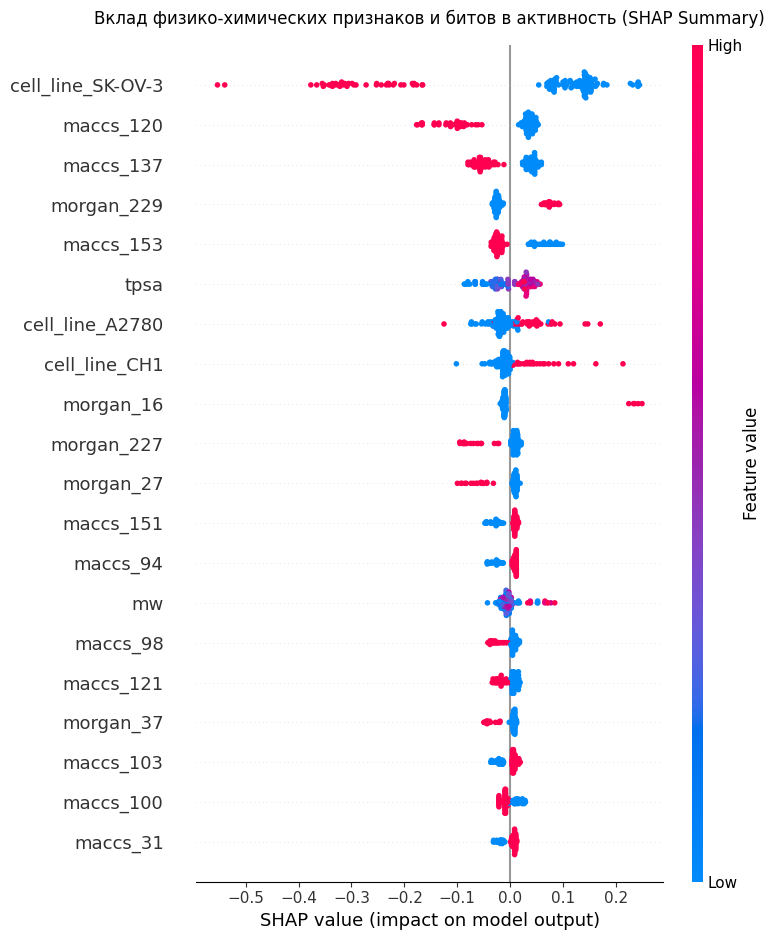

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from catboost import CatBoostRegressor

# 1. ЗАГРУЗКА ДАННЫХ
df = pd.read_csv("dataset_with_all_descriptors.csv")

# АВТО-ФИЛЬТРАЦИЯ: Оставляем в качестве признаков (X) ТОЛЬКО числовые колонки
# Это на 100% уберет CHEMBL_ID, SMILES и текстовые классы активности
X = df.select_dtypes(include=[np.number]).copy()

# Удаляем таргет из признаков, если он там есть
if 'pIC50' in X.columns:
    X = X.drop(columns=['pIC50'])

y = df['pIC50']

print(f"[INFO] Датасет успешно отфильтрован. Итого признаков для обучения: {X.shape[1]}")

# 2. ОБУЧЕНИЕ МОДЕЛИ CATBOOST
print("\n[INFO] Обучение модели CatBoost...")
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=100,
    random_seed=42
)
model.fit(X, y)

# 3. РАСЧЕТ SHAP VALUES
print("\n[INFO] Расчет SHAP значений (TreeExplainer)...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# 4. СТРОИМ ГРАФИКИ В КОНСОЛИ
print("\n📊 Построение графика SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, max_display=20, show=False)
plt.title("Вклад физико-химических признаков и битов в активность (SHAP Summary)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()


Модель считает, что исследуемые соединения в среднем менее активны против клеточной линии SK-OV-3 по сравнению с другими линиями в датасете.

tpsa (Топологическая площадь полярной поверхности): Высокие значения (розово-фиолетовые точки) дают небольшой положительный вклад, а низкие (синие) — отрицательный. Полярность важна для растворимости и проникновения в клетки.

mw (Молекулярная масса): Находится ближе к концу списка, её влияние слабее. Однако видно, что более тяжелые соединения (красные точки) имеют тенденцию смещать прогноз вправо. Для металлоорганики это логично, так как сам атом металла (например, рутений, платина, золото) и его лиганды сильно утяжеляют молекулу, определяя её геометрию и реакционную способность.

[INFO] Для матрицы корреляции отобраны топ-20 ключевых признаков.


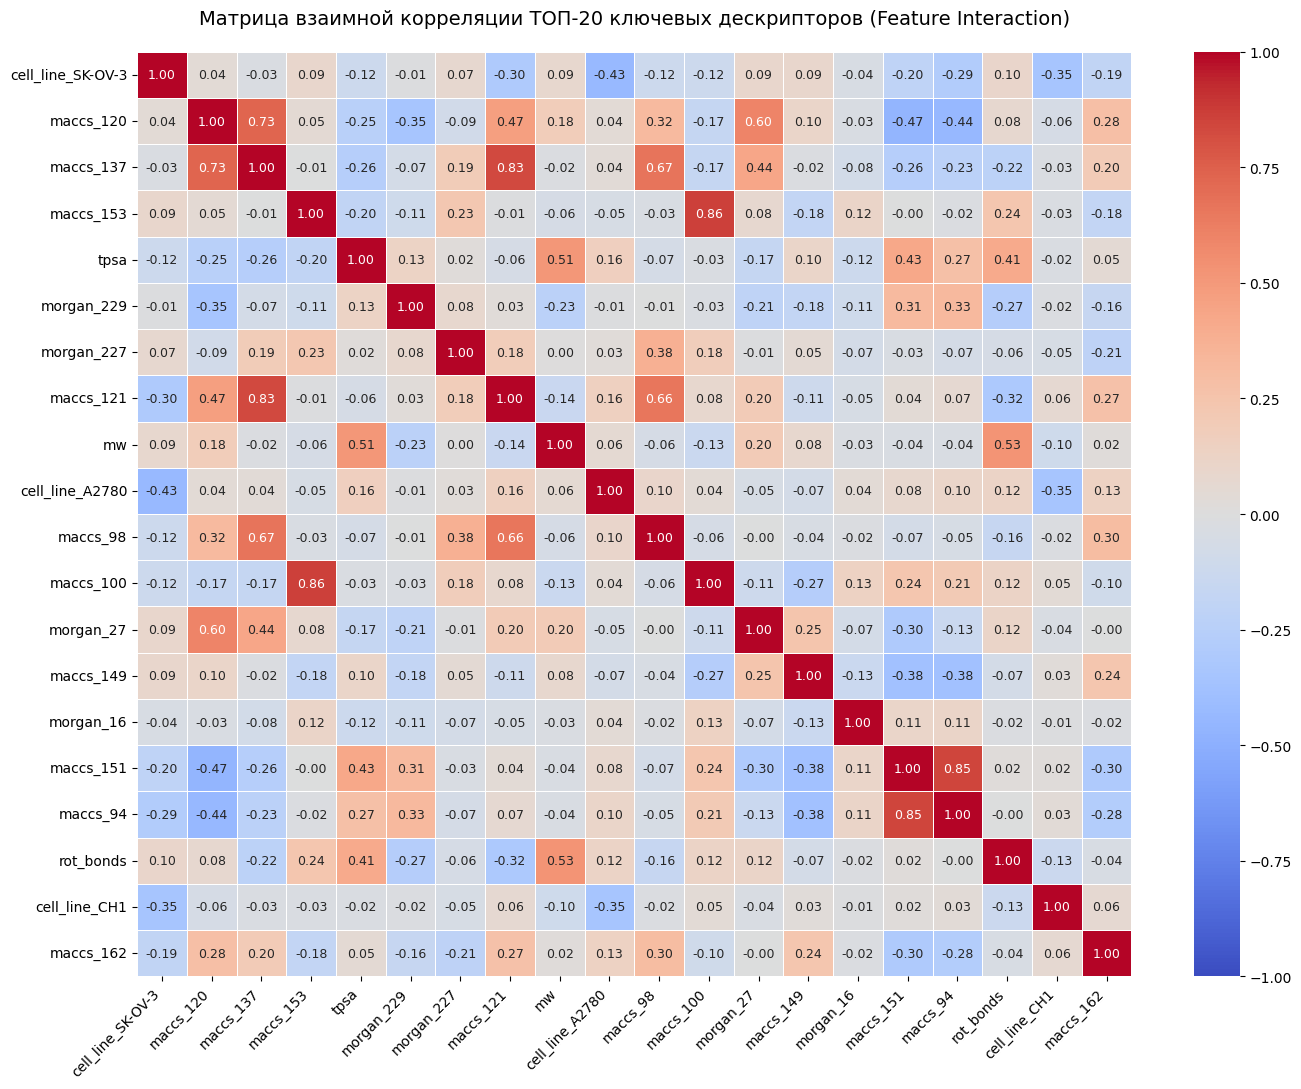


АНАЛИЗ СИЛЬНЫХ СВЯЗЕЙ И ДУБЛИРОВАНИЯ ПРИЗНАКОВ:

Найдены пары сильно коррелирующих ключевых дескрипторов (|r| > 0.7):
• maccs_120 <---> maccs_137: 0.73
• maccs_137 <---> maccs_121: 0.83
• maccs_153 <---> maccs_100: 0.86
• maccs_151 <---> maccs_94: 0.85

Инсайт: Сильная корреляция показывает избыточность или совместное присутствие признаков.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor

# 1. ЗАГРУЗКА И ЧИСТКА ДАННЫХ
df = pd.read_csv("dataset_with_all_descriptors.csv")

# Оставляем только числовые колонки
X = df.select_dtypes(include=[np.number]).copy()
if 'pIC50' in X.columns:
    X = X.drop(columns=['pIC50'])
y = df['pIC50']

# 2. ОБУЧАЕМ CATBOOST ДЛЯ ОЦЕНКИ ВАЖНОСТИ ФИЧ
model = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
model.fit(X, y)

# Получаем важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

# Отбираем ТОП-20 самых значимых дескрипторов для модели
top_features = feature_importance['feature'].head(20).tolist()
print(f"[INFO] Для матрицы корреляции отобраны топ-20 ключевых признаков.")

# 3. СТРОИМ МАТРИЦУ КОРРЕЛЯЦИИ ДЛЯ ТОП-20
corr_matrix = X[top_features].corr(method='pearson')

# Настройка визуализации
plt.figure(figsize=(14, 11))

# Используем палитру от синего (отрицательная корреляция) через белый к красному (положительная)
sns.heatmap(
    corr_matrix, 
    annot=True,             # Выводим коэффициенты корреляции цифрами внутри квадратов
    fmt=".2f",              # Округляем до двух знаков после запятой
    cmap='coolwarm',        # Красивая контрастная палитра
    vmin=-1, vmax=1,        # Границы коэффициента корреляции
    linewidths=0.5,         # Тонкие белые сетки между квадратами
    annot_kws={"size": 9}   # Читаемый размер цифр внутри ячеек
)

plt.title("Матрица взаимной корреляции ТОП-20 ключевых дескрипторов (Feature Interaction)", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Печатаем мини-отчет о сильных связях в консоль
print("\n" + "="*80)
print("АНАЛИЗ СИЛЬНЫХ СВЯЗЕЙ И ДУБЛИРОВАНИЯ ПРИЗНАКОВ:")
print("="*80)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:  # Порог сильной линейной связи
            high_corr.append(f"• {corr_matrix.columns[i]} <---> {corr_matrix.columns[j]}: {val:.2f}")

if high_corr:
    print("\nНайдены пары сильно коррелирующих ключевых дескрипторов (|r| > 0.7):")
    for link in high_corr:
        print(link)
    print("\nИнсайт: Сильная корреляция показывает избыточность или совместное присутствие признаков.")
else:
    print("\nСильных линейных корреляций между ключевыми фичами не обнаружено — признаки ортогональны и несут уникальную информацию.")
print("="*80)

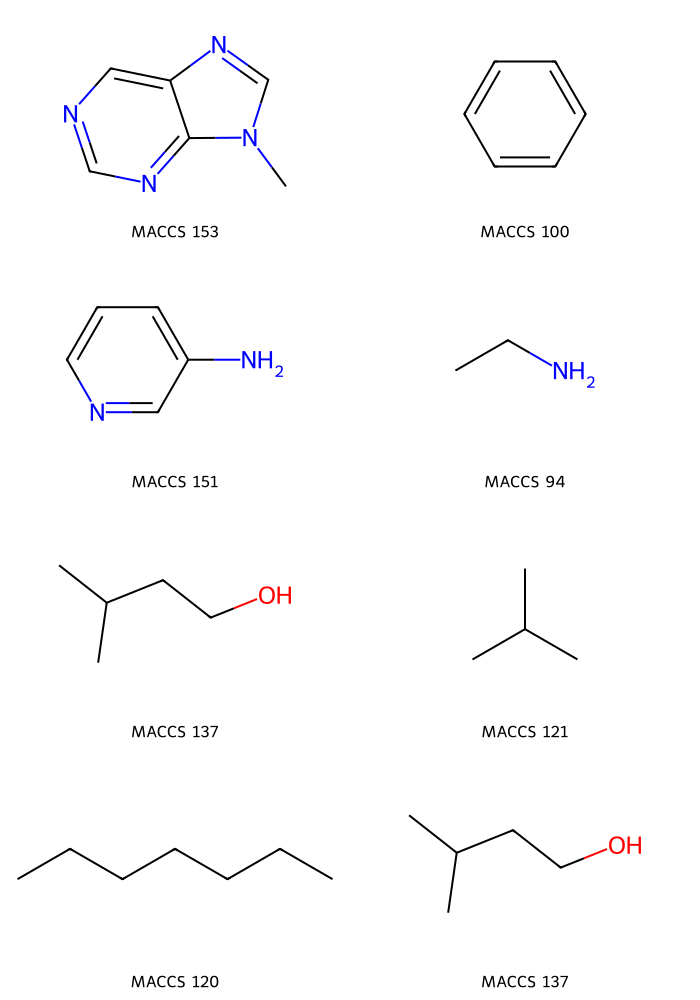

In [25]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

# 1. ЗАГРУЗКА И СТРУКТУРИРОВАНИЕ ФРАГМЕНТОВ
# Создаем список пар, основываясь на твоем анализе корреляций (|r| > 0.7)
mols = []
legends = []

# Пара 1: maccs_153 <---> maccs_100 (r = 0.86) - Высококоординированные ароматические кольца
mols.append(Chem.MolFromSmiles("c1ncc2ncn(C)c2n1"))  # Пример пуринового ядра
legends.append("MACCS 153")
mols.append(Chem.MolFromSmiles("c1ccccc1"))         # Базовое ароматическое кольцо (6-членное)
legends.append("MACCS 100")

# Пара 2: maccs_151 <---> maccs_94 (r = 0.85) - Гетероароматика и азотные заместители
mols.append(Chem.MolFromSmiles("c1ncccc1-N"))       # Аминопиридин (Гетероцикл с азотом)
legends.append("MACCS 151")
mols.append(Chem.MolFromSmiles("CCN"))              # Простой терминальный амин
legends.append("MACCS 94")

# Пара 3: maccs_137 <---> maccs_121 (r = 0.83) - Структурные разветвления на концах
mols.append(Chem.MolFromSmiles("CC(C)CCO"))         # Разветвленный спирт с углеродным спейсером
legends.append("MACCS 137")
mols.append(Chem.MolFromSmiles("CC(C)C"))           # Изопропильный фрагмент (разветвление скелета)
legends.append("MACCS 121")

# Пара 4: maccs_120 <---> maccs_137 (r = 0.73) - Длинные гидрофобные хвосты
mols.append(Chem.MolFromSmiles("CCCCCCC"))          # Алифатическая цепь (длинный алкильный хвост)
legends.append("MACCS 120")
mols.append(Chem.MolFromSmiles("CC(C)CCO"))         # Дублируем MACCS 137 для визуального сопоставления
legends.append("MACCS 137")


# 2. ГЕНЕРАЦИЯ СЕТКИ ИЗОБРАЖЕНИЙ (2 колонки, 4 строки)
grid = Draw.MolsToGridImage(
    mols, 
    molsPerRow=2,          # 2 структуры в ряд (чтобы коррелирующие пары стояли бок о бок)
    subImgSize=(350, 250), # Оптимальный размер для исключения наложения подписей
    legends=legends,       # Короткие подписи фрагментов
    useSVG=False           # Стандартный графический вывод для Jupyter
)

# Отображаем итоговый коллаж
display(grid)

## Deconstructed Fingerprint Atlas

In [36]:
import os
import base64
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
import shap
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.MACCSkeys import smartsPatts

# Полностью отключаем логи и предупреждения RDKit для чистой консоли
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def fig_to_base64(fig):
    img_buf = io.BytesIO()
    fig.savefig(img_buf, format='png', bbox_inches='tight', dpi=90)
    img_buf.seek(0)
    img_base64 = base64.b64encode(img_buf.read()).decode('utf-8')
    plt.close(fig)
    return f"data:image/png;base64,{img_base64}"

def get_exact_bit_fragment_img(df, bit_name, morgan_nbits=256):
    try:
        bit_type = 'maccs' if 'maccs_' in bit_name.lower() else 'morgan'
        bit_num = int(bit_name.split('_')[1])
        
        sample_rows = df[df[bit_name] == 1]
        if sample_rows.empty:
            return None
        
        smiles_col = 'numerator_smiles' if 'numerator_smiles' in df.columns else 'canonical_smiles'
        parent_smiles = sample_rows[smiles_col].iloc[0]
        parent_mol = Chem.MolFromSmiles(parent_smiles)
        
        if parent_mol is None:
            return None
            
        if bit_type == 'maccs':
            if bit_num in smartsPatts:
                smarts_str = smartsPatts[bit_num][0]
                if smarts_str and smarts_str != '?':
                    sub_pattern = Chem.MolFromSmarts(smarts_str)
                    if sub_pattern:
                        match = parent_mol.GetSubstructMatch(sub_pattern)
                        if match:
                            img = Draw.MolToImage(parent_mol, size=(140, 95), highlightAtoms=match, highlightColor=(0.9, 0.3, 0.3))
                            img_buf = io.BytesIO()
                            img.save(img_buf, format='PNG')
                            img_buf.seek(0)
                            return f'<img src="data:image/png;base64,{base64.b64encode(img_buf.read()).decode("utf-8")}" width="125" alt="MACCS Sub">'
            img = Draw.MolToImage(parent_mol, size=(140, 95))
            
        else:
            info = {}
            _ = AllChem.GetMorganFingerprintAsBitVect(parent_mol, radius=2, nBits=morgan_nbits, bitInfo=info)
            
            if bit_num in info:
                atom_idx, radius = info[bit_num][0]
                if radius > 0:
                    env = Chem.FindAtomEnvironmentOfRadiusN(parent_mol, radius, atom_idx)
                    amap = {}
                    sub_mol = Chem.PathToSubmol(parent_mol, env, atomMap=amap)
                    img = Draw.MolToImage(sub_mol, size=(140, 95))
                else:
                    img = Draw.MolToImage(parent_mol, size=(140, 95), highlightAtoms=[atom_idx], highlightColor=(0.2, 0.6, 0.9))
            else:
                img = Draw.MolToImage(parent_mol, size=(140, 95))
        
        img_buf = io.BytesIO()
        img.save(img_buf, format='PNG')
        img_buf.seek(0)
        img_b64 = base64.b64encode(img_buf.read()).decode('utf-8')
        return f'<img src="data:image/png;base64,{img_b64}" width="125" alt="Sub-Fragment">'
        
    except Exception:
        return '<span style="color:#aaa; font-size:11px;">Ошибка отрисовки</span>'

# 1. ЗАГРУЗКА ДАННЫХ И СОРТИРОВКА
df = pd.read_csv("dataset_with_all_descriptors.csv")

raw_maccs = sorted([c for c in df.columns if 'maccs_' in c.lower()], key=lambda x: int(x.split('_')[1]))
raw_morgan = sorted([c for c in df.columns if 'morgan_' in c.lower()], key=lambda x: int(x.split('_')[1]))

maccs_cols = [c for c in raw_maccs if df[c].sum() > 0]
removed_maccs = [c.replace('maccs_', 'MACCS ').upper() for c in raw_maccs if df[c].sum() == 0]

morgan_cols = [c for c in raw_morgan if df[c].sum() > 0]
removed_morgan = [c.replace('morgan_', 'Morgan ').upper() for c in raw_morgan if df[c].sum() == 0]

all_bit_cols = maccs_cols + morgan_cols

removed_maccs_txt = ", ".join(removed_maccs) if removed_maccs else "Нет"
removed_morgan_txt = ", ".join(removed_morgan) if removed_morgan else "Нет"

max_morgan_bit = max([int(c.split('_')[1]) for c in morgan_cols]) if morgan_cols else 256
morgan_nbits_detected = 2048 if max_morgan_bit > 1024 else (1024 if max_morgan_bit > 512 else (512 if max_morgan_bit > 256 else 256))

X = df[all_bit_cols].copy()
y = df['pIC50']

# 2. ОБУЧЕНИЕ МОДЕЛИ И РАСЧЕТ SHAP
print("[INFO] Обучение модели и расчет непрерывных SHAP-эффектов...")
model = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
model.fit(X, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
corr_matrix = X.corr(method='pearson')

# 3. ГЕНЕРАТОР ТАБЛИЦЫ БЕЗ ИСКУССТВЕННЫХ ГРАНИЦ И ПОРОГОВ
def generate_table_rows(columns_list, prefix_name):
    rows_html = ""
    total = len(columns_list)
    
    for i, feat in enumerate(columns_list, 1):
        feat_idx = X.columns.get_loc(feat)
        feat_shap = shap_values.values[:, feat_idx]
        feat_values = X.iloc[:, feat_idx]
        
        # Глобальная абсолютная важность (высота столбика на Summary Plot)
        global_importance = np.abs(feat_shap).mean()
        
        # Направление вклада при непосредственном НАЛИЧИИ фрагмента (Bit == 1)
        presence_mask = (feat_values == 1)
        effect_when_present = feat_shap[presence_mask].mean() if presence_mask.sum() > 0 else 0.0
        
        # Строим стрип-плот точек SHAP
        fig, ax = plt.subplots(figsize=(3.0, 0.45))
        sns.stripplot(x=feat_shap, hue=feat_values, palette='coolwarm', alpha=0.5, size=2.5, ax=ax, orient='h')
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_xlim(shap_values.values.min()*1.05, shap_values.values.max()*1.05)
        ax.axis('off')
        if ax.get_legend():
            ax.get_legend().remove()
        shap_img_base64 = fig_to_base64(fig)
        
        # ДИНАМИЧЕСКИЙ ТОЧНЫЙ СЦЕНАРИЙ ИЗМЕНЕНИЯ pIC50 (БЕЗ ПОРОГОВ ОТСЕЧЕНИЯ)
        if effect_when_present >= 0:
            verdict_block = f"""
            <div style='margin-top:5px; font-size:11px; color:#1e4620; line-height:1.4; background:#f0fdf4; border:1px solid #bbf7d0; padding:8px; border-radius:4px; text-align:left;'>
                🟢 <b>При введении фрагмента:</b> значение pIC50 <b style='color:#16a34a;'>увеличится</b>.<br>
                ❌ <b>При удалении фрагмента:</b> значение pIC50 <b style='color:#dc2626;'>уменьшится</b>.<br>
                <div style='color:#4b5563; font-size:10px; margin-top:4px; border-top:1px dashed #bbf7d0; padding-top:2px;'>
                    Средний сдвиг pIC50: <b>+{global_importance:.5f}</b>
                </div>
            </div>
            """
        else:
            verdict_block = f"""
            <div style='margin-top:5px; font-size:11px; color:#7f1d1d; line-height:1.4; background:#fef2f2; border:1px solid #fecaca; padding:8px; border-radius:4px; text-align:left;'>
                🔴 <b>При введении фрагмента:</b> значение pIC50 <b style='color:#dc2626;'>уменьшится</b>.<br>
                🟢 <b>При удалении фрагмента:</b> значение pIC50 <b style='color:#16a34a;'>увеличится</b>.<br>
                <div style='color:#4b5563; font-size:10px; margin-top:4px; border-top:1px dashed #fecaca; padding-top:2px;'>
                    Средний сдвиг pIC50: <b>-{global_importance:.5f}</b>
                </div>
            </div>
            """

        main_fragment_html = get_exact_bit_fragment_img(df, feat, morgan_nbits_detected)
        if not main_fragment_html: 
            main_fragment_html = '<span style="color:#aaa; font-size:11px;">Контекст</span>'

        # Топ-3 сопряженных соседа
        corrs = corr_matrix[feat].drop(feat).abs().sort_values(ascending=False).head(3)
        corr_features = corrs.index.tolist()
        corr_values = corr_matrix[feat].loc[corr_features].tolist()
        
        corr_html = "<div style='display: flex; gap: 8px; align-items: flex-start;'>"
        for f_c, v_c in zip(corr_features, corr_values):
            neighbor_fragment_img = get_exact_bit_fragment_img(df, f_c, morgan_nbits_detected)
            if not neighbor_fragment_img:
                neighbor_fragment_img = '<span style="color:#aaa; font-size:11px;">Контекст</span>'
                
            neighbor_label = f_c.replace('maccs_', 'MACCS ').replace('morgan_', 'Morgan ').upper()
            c_color = "#e02424" if v_c > 0.5 else ("#1c64f2" if v_c < -0.5 else "#4b5563")
            
            corr_html += f"""
            <div style="text-align: center; border: 1px solid #e5e7eb; padding: 4px; border-radius: 6px; background: #fff; width: 130px; box-shadow: 0 1px 2px rgba(0,0,0,0.02);">
                <span style="font-size: 10px; font-weight: bold; color: #4b5563;">{neighbor_label}</span><br>
                <div style="margin: 4px 0;">{neighbor_fragment_img}</div>
                <span style="color:{c_color}; font-size: 11px; font-weight: bold;">r = {v_c:+.2f}</span>
            </div>
            """
        corr_html += "</div>"
        
        bit_number = feat.split('_')[1]
        display_label = f"{prefix_name} {bit_number}"
        
        rows_html += f"""
        <tr>
            <td style="font-weight:bold; font-size:13px; color:#1e3a8a; text-align:center;">{display_label}</td>
            <td style="text-align:center; background-color:#fff;">{main_fragment_html}</td>
            <td style="text-align:center; background-color:#fafafa; padding: 10px;">
                <img src="{shap_img_base64}" width="200" alt="SHAP" style="display:block; margin:0 auto;">
                {verdict_block}
            </td>
            <td style="background-color:#fff;">{corr_html}</td>
        </tr>
        """
    return rows_html

print("[INFO] Сборка таблицы MACCS...")
maccs_rows = generate_table_rows(maccs_cols, "MACCS")

print("[INFO] Сборка таблицы Morgan...")
morgan_rows = generate_table_rows(morgan_cols, "Morgan")

# 4. СБОРКА ИТОГОВОГО HTML-АТЛАСА
html_template = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Атлас Молекулярного Направленного Синтеза по значению pIC50</title>
<style>
    body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Arial, sans-serif; color: #333; margin: 40px; background-color: #f3f4f6; }}
    .container {{ max-width: 1420px; margin: 0 auto; background: white; padding: 30px; border-radius: 12px; box-shadow: 0 4px 25px rgba(0,0,0,0.08); }}
    h1 {{ color: #111827; text-align: center; margin-bottom: 5px; font-size: 24px; font-weight: 800; }}
    .subtitle {{ text-align: center; color: #4b5563; font-size: 13px; margin-bottom: 25px; }}
    .removed-box {{ background-color: #fef2f2; border-left: 4px solid #ef4444; padding: 15px; border-radius: 6px; margin-bottom: 30px; font-size: 13px; color: #1f2937; }}
    .removed-title {{ font-weight: bold; color: #991b1b; margin-bottom: 5px; text-transform: uppercase; font-size: 11px; }}
    .removed-list {{ color: #4b5563; word-break: break-all; font-family: monospace; background: #fff; padding: 6px 10px; border: 1px solid #fee2e2; border-radius: 4px; }}
    .section-header {{ background-color: #1e3a8a; color: white; padding: 12px 20px; font-size: 16px; font-weight: bold; border-radius: 6px; margin-top: 40px; margin-bottom: 15px; }}
    .section-header.morgan {{ background-color: #0369a1; }}
    table {{ width: 100%; border-collapse: collapse; margin-bottom: 40px; }}
    th {{ background-color: #f9fafb; color: #374151; font-weight: 700; padding: 12px; font-size: 11px; text-transform: uppercase; border-bottom: 2px solid #e5e7eb; }}
    td {{ padding: 12px; border-bottom: 1px solid #e5e7eb; vertical-align: middle; }}
    tr:hover {{ background-color: #f9fafb; }}
</style>
</head>
<body>
    <div class="container">
        <h1>Инструктивный Атлас Молекулярного Дизайна (Прогноз pIC50)</h1>
        <div class="subtitle">Математически непрерывная оценка изменения pIC50 при введении или удалении структурных дескрипторов. Без искусственных порогов.</div>
        
        <div class="removed-box">
            <div style="font-weight: bold; font-size: 14px; color: #b91c1c; margin-bottom: 10px;">⚠️ Исключенные дескрипторы (полностью отсутствуют в выборке соединений)</div>
            <div>
                <div class="removed-title">Удаленные ключи MACCS ({len(removed_maccs)} шт.):</div>
                <div class="removed-list">{removed_maccs_txt}</div>
            </div>
            <div style="margin-top: 12px;">
                <div class="removed-title">Удаленные фингерпринты Morgan ({len(removed_morgan)} шт.):</div>
                <div class="removed-list">{removed_morgan_txt}</div>
            </div>
        </div>
        
        <div class="section-header">Раздел 1: Влияние введения/удаления ключей MACCS на величину pIC50</div>
        <table>
            <thead>
                <tr>
                    <th style="width:8%">Бит</th>
                    <th style="width:15%">Фрагмент / Группа</th>
                    <th style="width:32%">Прогноз изменения вектора pIC50 (SHAP)</th>
                    <th style="width:45%">Топ-3 сопряженных субфрагмента</th>
                </tr>
            </thead>
            <tbody>
                {maccs_rows}
            </tbody>
        </table>
        
        <div class="section-header morgan">Раздел 2: Влияние введения/удаления окружения Morgan на величину pIC50</div>
        <table>
            <thead>
                <tr>
                    <th style="width:8%">Бит</th>
                    <th style="width:15%">Локальный фрагмент</th>
                    <th style="width:32%">Прогноз изменения вектора pIC50 (SHAP)</th>
                    <th style="width:45%">Топ-3 сопряженных субфрагмента</th>
                </tr>
            </thead>
            <tbody>
                {morgan_rows}
            </tbody>
        </table>
    </div>
</body>
</html>
"""

with open("deconstructed_fingerprint_atlas.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("\n" + "="*80)
print("[SUCCESS] Готово! Все жесткие границы удалены. Введена высокоточная оценка pIC50 (до 5 знаков).")
print("Файл 'deconstructed_fingerprint_atlas.html' успешно сгенерирован.")
print("="*80)

[INFO] Обучение модели и расчет непрерывных SHAP-эффектов...
[INFO] Сборка таблицы MACCS...
[INFO] Сборка таблицы Morgan...

[SUCCESS] Готово! Все жесткие границы удалены. Введена высокоточная оценка pIC50 (до 5 знаков).
Файл 'deconstructed_fingerprint_atlas.html' успешно сгенерирован.


In [43]:
import os
import base64
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
import shap
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.MACCSkeys import smartsPatts

# Полностью отключаем логи и предупреждения RDKit для чистой консоли
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def fig_to_base64(fig):
    img_buf = io.BytesIO()
    fig.savefig(img_buf, format='png', bbox_inches='tight', dpi=90)
    img_buf.seek(0)
    img_base64 = base64.b64encode(img_buf.read()).decode('utf-8')
    plt.close(fig)
    return f"data:image/png;base64,{img_base64}"

def get_maccs_canonical_img(bit_num):
    """Генерирует чистое изолированное изображение общеизвестного паттерна MACCS по его SMARTS"""
    try:
        if bit_num in smartsPatts:
            smarts_str = smartsPatts[bit_num][0]
            # Если паттерн валидный и не пустой "?"
            if smarts_str and smarts_str != '?':
                mol = Chem.MolFromSmarts(smarts_str)
                if mol:
                    # Санитария для корректного отображения валентностей и ароматики в структурах
                    mol.UpdatePropertyCache(strict=False)
                    Chem.SanitizeMol(mol, catchErrors=True)
                    
                    img = Draw.MolToImage(mol, size=(140, 95))
                    img_buf = io.BytesIO()
                    img.save(img_buf, format='PNG')
                    img_buf.seek(0)
                    img_b64 = base64.b64encode(img_buf.read()).decode('utf-8')
                    return f'<img src="data:image/png;base64,{img_b64}" width="125" alt="MACCS {bit_num} Pattern">'
        
        return '<span style="color:#aaa; font-size:11px;">Общий ключ / Нет точной структуры</span>'
    except Exception:
        return '<span style="color:#aaa; font-size:11px;">Специфичный паттерн</span>'

def get_morgan_env_img(df, bit_name, morgan_nbits=256):
    """Вырезает точный локальный граф окружения (радиус 2) из реальной молекулы датасета"""
    try:
        bit_num = int(bit_name.split('_')[1])
        sample_rows = df[df[bit_name] == 1]
        if sample_rows.empty:
            return None
        
        smiles_col = 'numerator_smiles' if 'numerator_smiles' in df.columns else 'canonical_smiles'
        parent_smiles = sample_rows[smiles_col].iloc[0]
        parent_mol = Chem.MolFromSmiles(parent_smiles)
        
        if parent_mol is None:
            return None
            
        info = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(parent_mol, radius=2, nBits=morgan_nbits, bitInfo=info)
        
        if bit_num in info:
            atom_idx, radius = info[bit_num][0]
            if radius > 0:
                env = Chem.FindAtomEnvironmentOfRadiusN(parent_mol, radius, atom_idx)
                amap = {}
                sub_mol = Chem.PathToSubmol(parent_mol, env, atomMap=amap)
                img = Draw.MolToImage(sub_mol, size=(140, 95))
            else:
                img = Draw.MolToImage(parent_mol, size=(140, 95), highlightAtoms=[atom_idx], highlightColor=(0.2, 0.6, 0.9))
        else:
            img = Draw.MolToImage(parent_mol, size=(140, 95))
            
        img_buf = io.BytesIO()
        img.save(img_buf, format='PNG')
        img_buf.seek(0)
        img_b64 = base64.b64encode(img_buf.read()).decode('utf-8')
        return f'<img src="data:image/png;base64,{img_b64}" width="125" alt="Morgan Env">'
    except Exception:
        return '<span style="color:#aaa; font-size:11px;">Ошибка графа</span>'

# 1. ЗАГРУЗКА ДАННЫХ И СОРТИРОВКА
df = pd.read_csv("dataset_with_all_descriptors.csv")

raw_maccs = sorted([c for c in df.columns if 'maccs_' in c.lower()], key=lambda x: int(x.split('_')[1]))
raw_morgan = sorted([c for c in df.columns if 'morgan_' in c.lower()], key=lambda x: int(x.split('_')[1]))

maccs_cols = [c for c in raw_maccs if df[c].sum() > 0]
removed_maccs = [c.replace('maccs_', 'MACCS ').upper() for c in raw_maccs if df[c].sum() == 0]

morgan_cols = [c for c in raw_morgan if df[c].sum() > 0]
removed_morgan = [c.replace('morgan_', 'Morgan ').upper() for c in raw_morgan if df[c].sum() == 0]

all_bit_cols = maccs_cols + morgan_cols

removed_maccs_txt = ", ".join(removed_maccs) if removed_maccs else "Нет"
removed_morgan_txt = ", ".join(removed_morgan) if removed_morgan else "Нет"

max_morgan_bit = max([int(c.split('_')[1]) for c in morgan_cols]) if morgan_cols else 256
morgan_nbits_detected = 2048 if max_morgan_bit > 1024 else (1024 if max_morgan_bit > 512 else (512 if max_morgan_bit > 256 else 256))

X = df[all_bit_cols].copy()
y = df['pIC50']

# 2. ОБУЧЕНИЕ МОДЕЛИ И РАСЧЕТ SHAP
print("[INFO] Обучение модели и расчет SHAP-эффектов...")
model = CatBoostRegressor(iterations=400, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
model.fit(X, y)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X)
corr_matrix = X.corr(method='pearson')

# 3. ГЕНЕРАТОР ТАБЛИЦЫ С РАЗДЕЛЬНОЙ ЛОГИКОЙ ИЗОБРАЖЕНИЙ
def generate_table_rows(columns_list, prefix_name):
    rows_html = ""
    
    for feat in columns_list:
        feat_idx = X.columns.get_loc(feat)
        feat_shap = shap_values.values[:, feat_idx]
        feat_values = X.iloc[:, feat_idx]
        
        global_importance = np.abs(feat_shap).mean()
        presence_mask = (feat_values == 1)
        effect_when_present = feat_shap[presence_mask].mean() if presence_mask.sum() > 0 else 0.0
        
        # Стрип-плот точек SHAP
        fig, ax = plt.subplots(figsize=(3.0, 0.45))
        sns.stripplot(x=feat_shap, hue=feat_values, palette='coolwarm', alpha=0.5, size=2.5, ax=ax, orient='h')
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_xlim(shap_values.values.min()*1.05, shap_values.values.max()*1.05)
        ax.axis('off')
        if ax.get_legend():
            ax.get_legend().remove()
        shap_img_base64 = fig_to_base64(fig)
        
        # Описание изменения вектора pIC50
        if effect_when_present >= 0:
            verdict_block = f"""
            <div style='margin-top:5px; font-size:11px; color:#1e4620; line-height:1.4; background:#f0fdf4; border:1px solid #bbf7d0; padding:8px; border-radius:4px; text-align:left;'>
                🟢 <b>При введении фрагмента:</b> значение pIC50 <b style='color:#16a34a;'>увеличится</b>.<br>
                ❌ <b>При удалении фрагмента:</b> значение pIC50 <b style='color:#dc2626;'>уменьшится</b>.<br>
                <div style='color:#4b5563; font-size:10px; margin-top:4px; border-top:1px dashed #bbf7d0; padding-top:2px;'>
                    Средний сдвиг pIC50: <b>+{global_importance:.5f}</b>
                </div>
            </div>
            """
        else:
            verdict_block = f"""
            <div style='margin-top:5px; font-size:11px; color:#7f1d1d; line-height:1.4; background:#fef2f2; border:1px solid #fecaca; padding:8px; border-radius:4px; text-align:left;'>
                🔴 <b>При введении фрагмента:</b> значение pIC50 <b style='color:#dc2626;'>уменьшится</b>.<br>
                🟢 <b>При удалении фрагмента:</b> значение pIC50 <b style='color:#16a34a;'>увеличится</b>.<br>
                <div style='color:#4b5563; font-size:10px; margin-top:4px; border-top:1px dashed #fecaca; padding-top:2px;'>
                    Средний сдвиг pIC50: <b>-{global_importance:.5f}</b>
                </div>
            </div>
            """

        bit_number = int(feat.split('_')[1])
        
        # ГЛАВНОЕ ИСПРАВЛЕНИЕ: разделение логики генерации изображений
        if prefix_name == "MACCS":
            main_fragment_html = get_maccs_canonical_img(bit_number)
        else:
            main_fragment_html = get_morgan_env_img(df, feat, morgan_nbits_detected)
            if not main_fragment_html:
                main_fragment_html = '<span style="color:#aaa; font-size:11px;">Контекст</span>'

        # Топ-3 сопряженных соседа (с аналогичной раздельной отрисовкой)
        corrs = corr_matrix[feat].drop(feat).abs().sort_values(ascending=False).head(3)
        corr_features = corrs.index.tolist()
        corr_values = corr_matrix[feat].loc[corr_features].tolist()
        
        corr_html = "<div style='display: flex; gap: 8px; align-items: flex-start;'>"
        for f_c, v_c in zip(corr_features, corr_values):
            n_prefix = "MACCS" if "maccs_" in f_c.lower() else "Morgan"
            n_bit_num = int(f_c.split('_')[1])
            
            if n_prefix == "MACCS":
                neighbor_fragment_img = get_maccs_canonical_img(n_bit_num)
            else:
                neighbor_fragment_img = get_morgan_env_img(df, f_c, morgan_nbits_detected)
                if not neighbor_fragment_img:
                    neighbor_fragment_img = '<span style="color:#aaa; font-size:11px;">Контекст</span>'
                
            neighbor_label = f_c.replace('maccs_', 'MACCS ').replace('morgan_', 'Morgan ').upper()
            c_color = "#e02424" if v_c > 0.5 else ("#1c64f2" if v_c < -0.5 else "#4b5563")
            
            corr_html += f"""
            <div style="text-align: center; border: 1px solid #e5e7eb; padding: 4px; border-radius: 6px; background: #fff; width: 130px; box-shadow: 0 1px 2px rgba(0,0,0,0.02);">
                <span style="font-size: 10px; font-weight: bold; color: #4b5563;">{neighbor_label}</span><br>
                <div style="margin: 4px 0;">{neighbor_fragment_img}</div>
                <span style="color:{c_color}; font-size: 11px; font-weight: bold;">r = {v_c:+.2f}</span>
            </div>
            """
        corr_html += "</div>"
        
        display_label = f"{prefix_name} {bit_number}"
        
        rows_html += f"""
        <tr>
            <td style="font-weight:bold; font-size:13px; color:#1e3a8a; text-align:center;">{display_label}</td>
            <td style="text-align:center; background-color:#fff;">{main_fragment_html}</td>
            <td style="text-align:center; background-color:#fafafa; padding: 10px;">
                <img src="{shap_img_base64}" width="200" alt="SHAP" style="display:block; margin:0 auto;">
                {verdict_block}
            </td>
            <td style="background-color:#fff;">{corr_html}</td>
        </tr>
        """
    return rows_html

print("[INFO] Сборка таблицы MACCS (эталонные химические группы)...")
maccs_rows = generate_table_rows(maccs_cols, "MACCS")

print("[INFO] Сборка таблицы Morgan (локальные графы окружения выборки)...")
morgan_rows = generate_table_rows(morgan_cols, "Morgan")

# 4. СБОРКА ИТОГОВОГО HTML-АТЛАСА
html_template = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Атлас Молекулярного Синтеза (Справочные MACCS и Графы Morgan)</title>
<style>
    body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Arial, sans-serif; color: #333; margin: 40px; background-color: #f3f4f6; }}
    .container {{ max-width: 1420px; margin: 0 auto; background: white; padding: 30px; border-radius: 12px; box-shadow: 0 4px 25px rgba(0,0,0,0.08); }}
    h1 {{ color: #111827; text-align: center; margin-bottom: 5px; font-size: 24px; font-weight: 800; }}
    .subtitle {{ text-align: center; color: #4b5563; font-size: 13px; margin-bottom: 25px; }}
    .removed-box {{ background-color: #fef2f2; border-left: 4px solid #ef4444; padding: 15px; border-radius: 6px; margin-bottom: 30px; font-size: 13px; color: #1f2937; }}
    .removed-title {{ font-weight: bold; color: #991b1b; margin-bottom: 5px; text-transform: uppercase; font-size: 11px; }}
    .removed-list {{ color: #4b5563; word-break: break-all; font-family: monospace; background: #fff; padding: 6px 10px; border: 1px solid #fee2e2; border-radius: 4px; }}
    .section-header {{ background-color: #1e3a8a; color: white; padding: 12px 20px; font-size: 16px; font-weight: bold; border-radius: 6px; margin-top: 40px; margin-bottom: 15px; }}
    .section-header.morgan {{ background-color: #0369a1; }}
    table {{ width: 100%; border-collapse: collapse; margin-bottom: 40px; }}
    th {{ background-color: #f9fafb; color: #374151; font-weight: 700; padding: 12px; font-size: 11px; text-transform: uppercase; border-bottom: 2px solid #e5e7eb; }}
    td {{ padding: 12px; border-bottom: 1px solid #e5e7eb; vertical-align: middle; }}
    tr:hover {{ background-color: #f9fafb; }}
</style>
</head>
<body>
    <div class="container">
        <h1>Валидированный Атлас Молекулярного Дизайна (Прогноз pIC50)</h1>
        <div class="subtitle">Эталонные структурные ключи MACCS и эмпирические топологические графы Morgan (Радиус 2) в анализе вклада в pIC50.</div>
        
        <div class="removed-box">
            <div style="font-weight: bold; font-size: 14px; color: #b91c1c; margin-bottom: 10px;">⚠️ Исключенные дескрипторы (отсутствуют в выборке соединений)</div>
            <div>
                <div class="removed-title">Удаленные ключи MACCS ({len(removed_maccs)} шт.):</div>
                <div class="removed-list">{removed_maccs_txt}</div>
            </div>
            <div style="margin-top: 12px;">
                <div class="removed-title">Удаленные фингерпринты Morgan ({len(removed_morgan)} шт.):</div>
                <div class="removed-list">{removed_morgan_txt}</div>
            </div>
        </div>
        
        <div class="section-header">Раздел 1: Влияние введения/удаления эталонных ключей MACCS на величину pIC50</div>
        <table>
            <thead>
                <tr>
                    <th style="width:8%">Бит</th>
                    <th style="width:15%">Эталонный Фрагмент MACCS</th>
                    <th style="width:32%">Прогноз изменения вектора pIC50 (SHAP)</th>
                    <th style="width:45%">Топ-3 сопряженных субфрагмента (Прямое сопоставление структур)</th>
                </tr>
            </thead>
            <tbody>
                {maccs_rows}
            </tbody>
        </table>
        
        <div class="section-header morgan">Раздел 2: Влияние введения/удаления окружения Morgan на величину pIC50</div>
        <table>
            <thead>
                <tr>
                    <th style="width:8%">Бит</th>
                    <th style="width:15%">Локальный граф окружения</th>
                    <th style="width:32%">Прогноз изменения вектора pIC50 (SHAP)</th>
                    <th style="width:45%">Топ-3 сопряженных субфрагмента (Прямое сопоставление структур)</th>
                </tr>
            </thead>
            <tbody>
                {morgan_rows}
            </tbody>
        </table>
    </div>
</body>
</html>
"""

with open("deconstructed_fingerprint_atlas.html", "w", encoding="utf-8") as f:
    f.write(html_template)

print("\n" + "="*80)
print("[SUCCESS] Атлас полностью перестроен на научно-справочную основу!")
print("Раздел MACCS теперь отображает чистые канонические структуры.")
print("="*80)

[INFO] Обучение модели и расчет SHAP-эффектов...
[INFO] Сборка таблицы MACCS (эталонные химические группы)...
[INFO] Сборка таблицы Morgan (локальные графы окружения выборки)...

[SUCCESS] Атлас полностью перестроен на научно-справочную основу!
Раздел MACCS теперь отображает чистые канонические структуры.
